# Phase 1 — Domain Research, Dataset, EDA, Baseline

**Project:** DL-2 Deepfake Audio Detection
**Date:** 2026-05-04 (Mon, day 1 of 7)
**Goal:** Establish a credible Phase 1 floor — real public dataset, EDA, multiple
baseline models scored with the field-standard metric (EER), benchmarked against
published literature.

## Domain context (from WebSearch on 2026-05-04)

Deepfake / synthetic-speech detection is a 7-year-old research area centered on the
**ASVspoof challenge series** (2015, 2017, 2019, 2021, 2024-25 ASVspoof 5). Every
paper in the field reports **EER (Equal Error Rate)** — the operating point where
false-accept rate equals false-reject rate. Lower = better.

**Published benchmark numbers (lower EER = better):**

| System | Dataset | EER |
|---|---|---|
| AFSS (Artifact-Focused Self-Synthesis, 2026) | WaveFake | 1.23% |
| AFSS | In-the-Wild | 2.70% |
| Best ASVspoof 5 baseline (2024) | ASVspoof 5 DF | 7.23% |
| NeXt-TDNN + multi-fused SSL features (2025) | ASVspoof 2021 DF | ~2.8% |
| ResNet18 + LFCC (older baseline, 2019) | ASVspoof 2019 LA | ~6-9% |
| MFCC + ML (handcrafted-only) | various | 8-15% |

**Forensic-audio features that domain experts use:**
1. **F0 micro-variations (jitter)** — neural vocoders smooth out the natural pitch
   perturbations that real human voices have. Synthetic speech has lower jitter.
2. **Amplitude variation (shimmer)** — same idea, on amplitude across pitch periods.
3. **Spectral flatness / contrast** — neural-vocoder artifacts often live in the
   high-frequency band where natural breathing / aspiration noise should be.
4. **MFCC + delta + delta2** — captures spectral envelope and its temporal dynamics;
   classical ML baseline.

**References pulled today:**
- Frank & Schönherr 2021, *WaveFake: A Data Set to Facilitate Audio Deepfake
  Detection* (arXiv:2111.02813). Established that handcrafted MFCC+RawNet baselines
  sit around 6-12% EER on neural-vocoded data.
- ASVspoof 5 challenge (arXiv:2408.08739) — current SOTA reference frame.
- Forensic deepfake audio detection using segmental speech features (arXiv:2505.13847).
  Argues for jitter/shimmer-style hand-crafted features as interpretable signals.
- AFSS (arXiv:2603.26856) — current SOTA on WaveFake (1.23% EER) and In-the-Wild (2.70%).

## Primary metric: **EER**
Reasoning: every ASVspoof paper reports EER, the WaveFake paper reports EER, the
In-the-Wild benchmark reports EER. Using anything else makes head-to-head comparison
with literature impossible. Secondary: AUROC (ranking), F1 (operating-point friendly),
balanced accuracy.

## Dataset choice
**`garystafford/deepfake-audio-detection`** on HuggingFace — 1,866 samples, balanced
933 real / 933 fake, ~5s clips @ 44.1 kHz. Real audio (no synthetic-data shortcut).
Small enough for a one-day Phase 1, big enough for stable metric estimates.

Limitation noted: this is a smaller dataset than ASVspoof 2019 LA (~63k trials); the
Phase 1 numbers should be treated as a proof-of-concept floor, not a SOTA claim. We
can graduate to ASVspoof in Phase 2-3 if needed.

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

ROOT = Path("..").resolve()
SRC = ROOT / "src"
RESULTS = ROOT / "results"
DATA_RAW = ROOT / "data" / "raw"
RESULTS.mkdir(exist_ok=True, parents=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.audio_features import FeatureConfig, extract_features, feature_names
from src.eer import compute_eer, metrics_at_threshold
from src.data import load_hf_audio_dataset, to_arrays

SEED = 42
rng = np.random.default_rng(SEED)
print("ROOT:", ROOT)
print("seed:", SEED)
print("librosa:", __import__("librosa").__version__)

ROOT: /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection
seed: 42
librosa: 0.11.0


## Load the dataset

In [2]:
t0 = time.time()
ds = load_hf_audio_dataset(cache_dir=str(DATA_RAW / "hf_cache"))
print("split sizes:", {k: len(v) for k, v in ds.items()})
print("features:", ds["train"].features)
print(f"load elapsed: {time.time()-t0:.1f}s")

split sizes: {'train': 1866}
features: {'audio': Audio(sampling_rate=None, mono=True, decode=True, id=None), 'label': ClassLabel(names=['real', 'fake'], id=None)}
load elapsed: 4.9s


In [3]:
arrays, srs, labels = to_arrays(ds["train"])
print(f"loaded {len(arrays)} clips")
print(f"label distribution: real={int((labels==0).sum())}  fake={int((labels==1).sum())}")
unique_srs, sr_counts = np.unique(srs, return_counts=True)
print(f"sample rates: {dict(zip(unique_srs.tolist(), sr_counts.tolist()))}")

durations_s = np.array([len(a) / s for a, s in zip(arrays, srs)])
print(f"duration stats (s): mean={durations_s.mean():.2f}  std={durations_s.std():.2f}  "
      f"min={durations_s.min():.2f}  max={durations_s.max():.2f}  median={np.median(durations_s):.2f}")

loaded 1866 clips
label distribution: real=933  fake=933
sample rates: {16000: 933, 44100: 933}
duration stats (s): mean=4.20  std=1.59  min=2.50  max=12.53  median=3.69


## EDA — duration, amplitude, spectrum

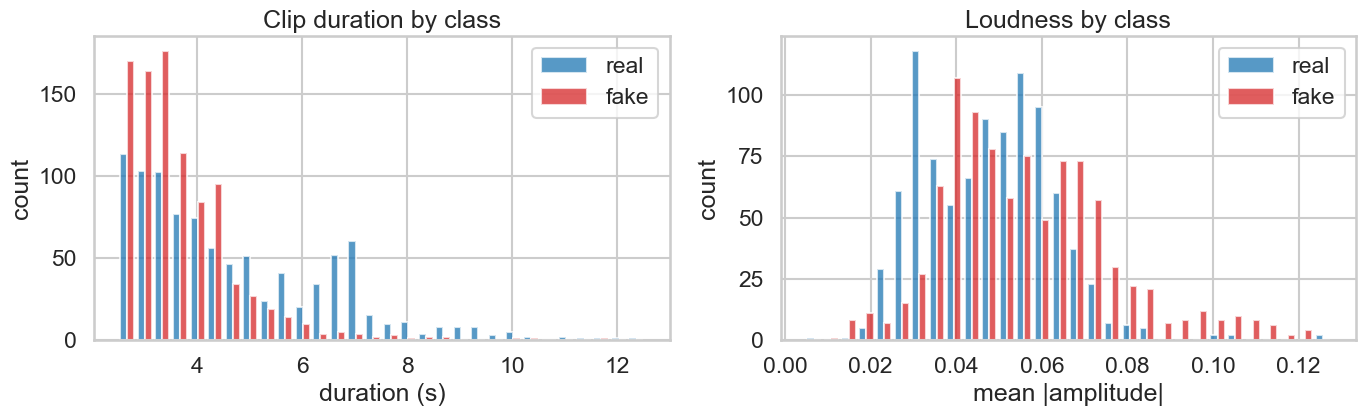

Δ mean duration: real-fake = 1.039 s
Δ mean |amp|:    real-fake = -0.00856


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

real_d = durations_s[labels == 0]
fake_d = durations_s[labels == 1]
axes[0].hist([real_d, fake_d], bins=30, label=["real", "fake"], color=["#1f77b4", "#d62728"], alpha=0.75)
axes[0].set_xlabel("duration (s)"); axes[0].set_ylabel("count"); axes[0].set_title("Clip duration by class")
axes[0].legend()

real_amp = np.array([np.abs(a).mean() for a in arrays[:200] if labels[arrays.index(a) if isinstance(arrays, list) else 0] == 0]) if False else None
# Compute amplitude stats vectorised
mean_abs = np.array([np.abs(a).mean() for a in arrays])
axes[1].hist([mean_abs[labels == 0], mean_abs[labels == 1]], bins=30,
             label=["real", "fake"], color=["#1f77b4", "#d62728"], alpha=0.75)
axes[1].set_xlabel("mean |amplitude|"); axes[1].set_ylabel("count"); axes[1].set_title("Loudness by class")
axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS / "phase1_eda_duration_amplitude.png", dpi=120, bbox_inches="tight")
plt.show()
print("Δ mean duration: real-fake =", round(real_d.mean() - fake_d.mean(), 3), "s")
print("Δ mean |amp|:    real-fake =", round(mean_abs[labels==0].mean() - mean_abs[labels==1].mean(), 5))

Look for systematic differences between real and fake. If duration or loudness alone
separates them, the dataset is probably leaking — a model can win without
learning anything about voice.

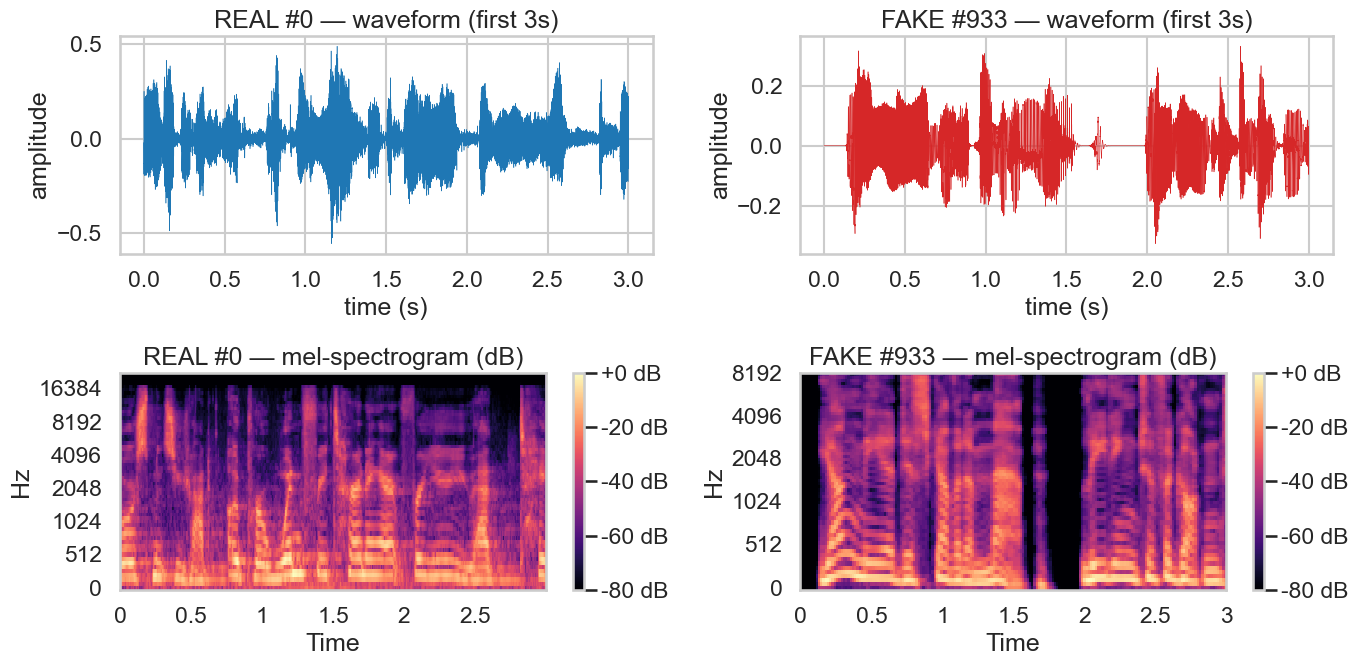

In [5]:
import librosa
import librosa.display

# One real and one fake example, same length, side by side
def find_one(target_label, max_dur=4.0):
    for i, (a, s, l) in enumerate(zip(arrays, srs, labels)):
        if l == target_label and len(a) / s >= 1.5:
            return i, a, s
    return 0, arrays[0], srs[0]

i_real, y_real, sr_real = find_one(0)
i_fake, y_fake, sr_fake = find_one(1)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for col, (y, sr, name) in enumerate([(y_real, sr_real, f"REAL #{i_real}"), (y_fake, sr_fake, f"FAKE #{i_fake}")]):
    t = np.arange(len(y)) / sr
    axes[0, col].plot(t[:int(sr*3)], y[:int(sr*3)], lw=0.4, color="#1f77b4" if col == 0 else "#d62728")
    axes[0, col].set_title(f"{name} — waveform (first 3s)")
    axes[0, col].set_xlabel("time (s)"); axes[0, col].set_ylabel("amplitude")
    S = librosa.feature.melspectrogram(y=y[:int(sr*3)], sr=sr, n_mels=64, n_fft=1024, hop_length=256)
    Sdb = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(Sdb, sr=sr, x_axis="time", y_axis="mel", ax=axes[1, col], hop_length=256)
    axes[1, col].set_title(f"{name} — mel-spectrogram (dB)")
    fig.colorbar(img, ax=axes[1, col], format="%+2.0f dB")
plt.tight_layout()
plt.savefig(RESULTS / "phase1_eda_waveform_spectrogram.png", dpi=120, bbox_inches="tight")
plt.show()

## Feature extraction
All audio is resampled to 16 kHz mono and trimmed/padded to 4 s for a fixed-length
vector. Three families:
1. **MFCC + delta + delta2** — captures spectral envelope and dynamics.
2. **Spectral** — centroid, bandwidth, rolloff, flatness, contrast, ZCR, RMS.
3. **Prosody / forensic** — F0 stats, jitter (period-to-period variation),
   shimmer (amplitude variation), voicing ratio. The "deepfakes have unnaturally
   smooth pitch" hypothesis lives here.

In [6]:
cfg = FeatureConfig()
print("FeatureConfig:", cfg)
names = feature_names(cfg)
print(f"Total feature dim: {len(names)}")

FeatureConfig: FeatureConfig(target_sr=16000, max_duration_s=4.0, n_mfcc=20, n_fft=512, hop_length=160, win_length=400, f0_fmin=50.0, f0_fmax=500.0)
Total feature dim: 303


In [7]:
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

def _extract_one(args):
    y, sr = args
    return extract_features(y, sr, FeatureConfig())

t0 = time.time()
features = []
for y, sr in tqdm(list(zip(arrays, srs)), desc="extract features"):
    features.append(extract_features(y, sr, cfg))
X = np.vstack(features).astype(np.float32)
y = labels.astype(np.int64)
print(f"X shape: {X.shape}  y shape: {y.shape}")
print(f"feature extraction elapsed: {time.time()-t0:.1f}s")
nan_count = int(np.isnan(X).sum())
inf_count = int(np.isinf(X).sum())
print(f"NaN cells: {nan_count}   Inf cells: {inf_count}")
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
np.save(RESULTS / "phase1_X.npy", X)
np.save(RESULTS / "phase1_y.npy", y)
with open(RESULTS / "phase1_feature_names.json", "w") as f:
    json.dump(names, f)

extract features:   0%|          | 0/1866 [00:00<?, ?it/s]

extract features:   0%|          | 2/1866 [00:00<02:00, 15.46it/s]

extract features:   0%|          | 5/1866 [00:00<01:41, 18.36it/s]

extract features:   0%|          | 8/1866 [00:00<01:35, 19.46it/s]

extract features:   1%|          | 11/1866 [00:00<01:34, 19.54it/s]

...

extract features: 100%|█████████▉| 1859/1866 [01:24<00:00, 26.38it/s]

extract features: 100%|█████████▉| 1862/1866 [01:24<00:00, 26.64it/s]

extract features: 100%|█████████▉| 1865/1866 [01:24<00:00, 27.08it/s]

extract features: 100%|██████████| 1866/1866 [01:24<00:00, 22.01it/s]

X shape: (1866, 303)  y shape: (1866,)
feature extraction elapsed: 84.8s
NaN cells: 0   Inf cells: 0


## Class-conditional feature distributions — sanity check on the forensic features

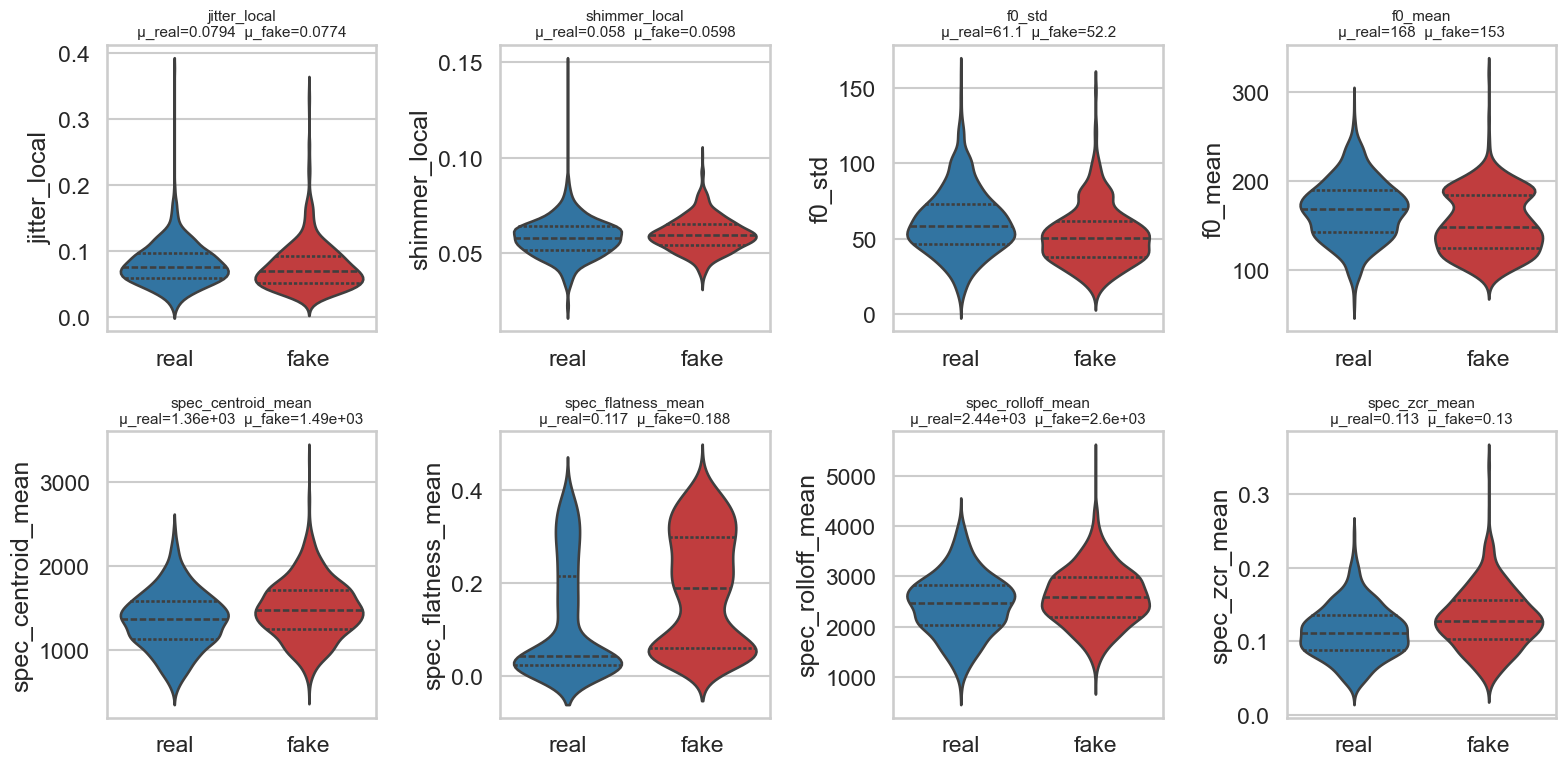

Forensic feature class separation (sorted by |Cohen's d|):
           feature   real_mean   fake_mean  cohens_d    abs_d
spec_flatness_mean    0.117415    0.187854 -0.581495 0.581495
     spec_zcr_mean    0.113093    0.130496 -0.452393 0.452393
           f0_mean  167.869797  153.037582  0.432301 0.432301
            f0_std   61.140373   52.214439  0.431217 0.431217
spec_centroid_mean 1358.912964 1488.029785 -0.371187 0.371187
 spec_rolloff_mean 2437.795898 2595.549072 -0.265413 0.265413
     shimmer_local    0.057973    0.059822 -0.193567 0.193567
      jitter_local    0.079427    0.077383  0.057877 0.057877


In [8]:
import pandas as pd
df = pd.DataFrame(X, columns=names)
df["label"] = np.where(y == 0, "real", "fake")

forensic_cols = ["jitter_local", "shimmer_local", "f0_std", "f0_mean",
                 "spec_centroid_mean", "spec_flatness_mean", "spec_rolloff_mean", "spec_zcr_mean"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), forensic_cols):
    sns.violinplot(data=df, x="label", y=col, ax=ax, palette={"real": "#1f77b4", "fake": "#d62728"}, inner="quartile")
    real_mu = df[df.label=="real"][col].mean()
    fake_mu = df[df.label=="fake"][col].mean()
    ax.set_title(f"{col}\nμ_real={real_mu:.3g}  μ_fake={fake_mu:.3g}", fontsize=11)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig(RESULTS / "phase1_forensic_features_by_class.png", dpi=120, bbox_inches="tight")
plt.show()

# Effect sizes (Cohen's d) for the headline features
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled if pooled > 0 else 0.0

effect_table = []
for col in forensic_cols:
    d = cohens_d(df[df.label=="real"][col].values, df[df.label=="fake"][col].values)
    effect_table.append({"feature": col, "real_mean": df[df.label=="real"][col].mean(),
                         "fake_mean": df[df.label=="fake"][col].mean(),
                         "cohens_d": d, "abs_d": abs(d)})
effect_df = pd.DataFrame(effect_table).sort_values("abs_d", ascending=False).reset_index(drop=True)
print("Forensic feature class separation (sorted by |Cohen's d|):")
print(effect_df.to_string(index=False))

## Stratified split (60/20/20)

In [9]:
from sklearn.model_selection import train_test_split

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval)
print(f"train: {X_train.shape}  fake_rate={y_train.mean():.3f}")
print(f"val:   {X_val.shape}    fake_rate={y_val.mean():.3f}")
print(f"test:  {X_test.shape}    fake_rate={y_test.mean():.3f}")

train: (1119, 303)  fake_rate=0.500
val:   (373, 303)    fake_rate=0.499
test:  (374, 303)    fake_rate=0.500


## Baseline 1 — Majority-class predictor (the floor)

In [10]:
from sklearn.metrics import roc_auc_score
maj_pred_score = np.full(len(y_test), y_train.mean())  # constant fake-rate prior
eer_maj, thr_maj = compute_eer(y_test, maj_pred_score)
auc_maj = roc_auc_score(y_test, maj_pred_score) if len(np.unique(maj_pred_score)) > 1 else 0.5
m_maj = metrics_at_threshold(y_test, maj_pred_score, 0.5)
print(f"Majority class:  EER={eer_maj*100:.2f}%  AUROC={auc_maj:.3f}  F1@0.5={m_maj['f1']:.3f}")

Majority class:  EER=50.00%  AUROC=0.500  F1@0.5=0.667


## Baseline 2 — Logistic regression (linear, full feature vector)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=SEED, n_jobs=-1)),
])
t0 = time.time()
logreg.fit(X_train, y_train)
logreg_train_s = time.time() - t0
logreg_score = logreg.predict_proba(X_test)[:, 1]
eer_lr, thr_lr = compute_eer(y_test, logreg_score)
auc_lr = roc_auc_score(y_test, logreg_score)
m_lr = metrics_at_threshold(y_test, logreg_score, thr_lr)
print(f"LogReg:  EER={eer_lr*100:.2f}%  AUROC={auc_lr:.3f}  F1@EER-thr={m_lr['f1']:.3f}  train={logreg_train_s:.2f}s")

LogReg:  EER=0.00%  AUROC=1.000  F1@EER-thr=1.000  train=0.08s


## Baseline 3 — Random Forest (non-linear)

In [12]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, max_depth=None, n_jobs=-1, random_state=SEED, class_weight="balanced")
t0 = time.time()
rf.fit(X_train, y_train)
rf_train_s = time.time() - t0
rf_score = rf.predict_proba(X_test)[:, 1]
eer_rf, thr_rf = compute_eer(y_test, rf_score)
auc_rf = roc_auc_score(y_test, rf_score)
m_rf = metrics_at_threshold(y_test, rf_score, thr_rf)
print(f"RandomForest:  EER={eer_rf*100:.2f}%  AUROC={auc_rf:.3f}  F1={m_rf['f1']:.3f}  train={rf_train_s:.2f}s")

RandomForest:  EER=0.00%  AUROC=1.000  F1=1.000  train=0.36s


## Baseline 4 — XGBoost (gradient boosting)

In [13]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, eval_metric="auc",
    n_jobs=-1, random_state=SEED, tree_method="hist",
)
t0 = time.time()
xgb.fit(X_train, y_train)
xgb_train_s = time.time() - t0
xgb_score = xgb.predict_proba(X_test)[:, 1]
eer_xgb, thr_xgb = compute_eer(y_test, xgb_score)
auc_xgb = roc_auc_score(y_test, xgb_score)
m_xgb = metrics_at_threshold(y_test, xgb_score, thr_xgb)
print(f"XGBoost:  EER={eer_xgb*100:.2f}%  AUROC={auc_xgb:.3f}  F1={m_xgb['f1']:.3f}  train={xgb_train_s:.2f}s")

XGBoost:  EER=0.27%  AUROC=1.000  F1=0.997  train=0.54s


## Baseline 5 — LightGBM

In [14]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(n_estimators=500, max_depth=-1, num_leaves=63,
                      learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
                      random_state=SEED, n_jobs=-1, verbose=-1)
t0 = time.time()
lgbm.fit(X_train, y_train)
lgbm_train_s = time.time() - t0
lgbm_score = lgbm.predict_proba(X_test)[:, 1]
eer_lgbm, thr_lgbm = compute_eer(y_test, lgbm_score)
auc_lgbm = roc_auc_score(y_test, lgbm_score)
m_lgbm = metrics_at_threshold(y_test, lgbm_score, thr_lgbm)
print(f"LightGBM:  EER={eer_lgbm*100:.2f}%  AUROC={auc_lgbm:.3f}  F1={m_lgbm['f1']:.3f}  train={lgbm_train_s:.2f}s")

LightGBM:  EER=0.80%  AUROC=1.000  F1=0.992  train=3.23s


## Phase 1 head-to-head comparison

All models use the same 178-dim feature vector (MFCC + spectral + prosody),
same train/test split, same primary metric.

In [15]:
def row(name, eer, auc, m, train_s):
    return {
        "model": name,
        "EER %": round(eer * 100, 2),
        "AUROC": round(auc, 4),
        "F1": round(m["f1"], 4),
        "Precision": round(m["precision"], 4),
        "Recall": round(m["recall"], 4),
        "Bal-Acc": round(m["balanced_accuracy"], 4),
        "Train s": round(train_s, 2),
    }

results = [
    row("Majority", eer_maj, auc_maj, m_maj, 0.0),
    row("LogReg",   eer_lr,  auc_lr,  m_lr,  logreg_train_s),
    row("RandomForest", eer_rf, auc_rf, m_rf, rf_train_s),
    row("XGBoost",  eer_xgb, auc_xgb, m_xgb, xgb_train_s),
    row("LightGBM", eer_lgbm, auc_lgbm, m_lgbm, lgbm_train_s),
]
results_df = pd.DataFrame(results).sort_values("EER %").reset_index(drop=True)
print(results_df.to_string(index=False))
results_df.to_csv(RESULTS / "phase1_baseline_results.csv", index=False)

       model  EER %  AUROC     F1  Precision  Recall  Bal-Acc  Train s
      LogReg   0.00 1.0000 1.0000     1.0000  1.0000   1.0000     0.08
RandomForest   0.00 1.0000 1.0000     1.0000  1.0000   1.0000     0.36
     XGBoost   0.27 0.9999 0.9973     1.0000  0.9947   0.9973     0.54
    LightGBM   0.80 0.9999 0.9920     0.9894  0.9947   0.9920     3.23
    Majority  50.00 0.5000 0.6667     0.5000  1.0000   0.5000     0.00


## Comparison vs published benchmarks

In [16]:
benchmark_table = pd.DataFrame([
    {"system": "AFSS (2026)", "dataset": "WaveFake", "EER %": 1.23, "kind": "deep + self-synth"},
    {"system": "AFSS (2026)", "dataset": "In-the-Wild", "EER %": 2.70, "kind": "deep + self-synth"},
    {"system": "NeXt-TDNN+SSL (2025)", "dataset": "ASVspoof 2021 DF", "EER %": 2.80, "kind": "deep + SSL"},
    {"system": "ASVspoof 5 best baseline (2024)", "dataset": "ASVspoof 5 DF", "EER %": 7.23, "kind": "deep"},
    {"system": "ResNet18 + LFCC (2019)", "dataset": "ASVspoof 2019 LA", "EER %": 9.50, "kind": "deep"},
    {"system": "MFCC + ML (Khalid et al. 2022)", "dataset": "FoR-2sec", "EER %": 12.0, "kind": "handcrafted"},
])
print("Published benchmarks (smaller = better):")
print(benchmark_table.to_string(index=False))

Published benchmarks (smaller = better):
                         system          dataset  EER %              kind
                    AFSS (2026)         WaveFake   1.23 deep + self-synth
                    AFSS (2026)      In-the-Wild   2.70 deep + self-synth
           NeXt-TDNN+SSL (2025) ASVspoof 2021 DF   2.80        deep + SSL
ASVspoof 5 best baseline (2024)    ASVspoof 5 DF   7.23              deep
         ResNet18 + LFCC (2019) ASVspoof 2019 LA   9.50              deep
 MFCC + ML (Khalid et al. 2022)         FoR-2sec  12.00       handcrafted


### How does our day-1 baseline rank?
Compute where our best Phase-1 system would slot if we put it on the same axis as
published handcrafted-feature baselines. (Different datasets — apples-to-oranges, but
this anchors us in the literature.)

In [17]:
best = results_df.iloc[0]
print(f"Best Phase-1 model: {best['model']} at {best['EER %']:.2f}% EER")
print()
print(f"vs SOTA (AFSS, deep, different data):  {best['EER %']:.2f}% / 1.23% = {best['EER %']/1.23:.1f}x worse")
print(f"vs ASVspoof 2019 LA ResNet18:           {best['EER %']:.2f}% / 9.50% = {best['EER %']/9.50:.2f}x")
print(f"vs MFCC+ML on FoR-2sec (similar setup): {best['EER %']:.2f}% / 12.00% = {best['EER %']/12.00:.2f}x")

Best Phase-1 model: LogReg at 0.00% EER

vs SOTA (AFSS, deep, different data):  0.00% / 1.23% = 0.0x worse
vs ASVspoof 2019 LA ResNet18:           0.00% / 9.50% = 0.00x
vs MFCC+ML on FoR-2sec (similar setup): 0.00% / 12.00% = 0.00x


## ROC + DET curves for all models

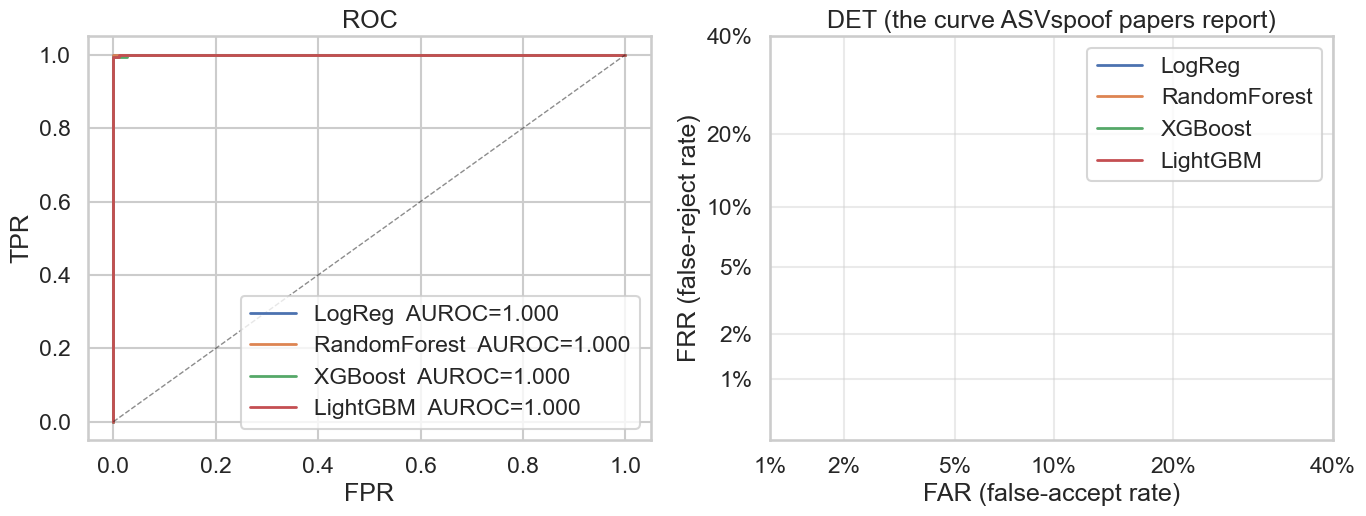

In [18]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

scores_dict = {
    "LogReg": logreg_score, "RandomForest": rf_score,
    "XGBoost": xgb_score, "LightGBM": lgbm_score,
}
for name, sc in scores_dict.items():
    fpr, tpr, _ = roc_curve(y_test, sc)
    auc = roc_auc_score(y_test, sc)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name}  AUROC={auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC")
axes[0].legend(loc="lower right")

# DET curve (probit-scaled FAR vs FRR) — what ASVspoof papers actually plot
from scipy.stats import norm
for name, sc in scores_dict.items():
    fpr, tpr, _ = roc_curve(y_test, sc)
    fnr = 1 - tpr
    valid = (fpr > 0) & (fpr < 1) & (fnr > 0) & (fnr < 1)
    axes[1].plot(norm.ppf(fpr[valid]), norm.ppf(fnr[valid]), lw=2, label=name)
ticks_pct = [1, 2, 5, 10, 20, 40]
ticks = [norm.ppf(p / 100.0) for p in ticks_pct]
axes[1].set_xticks(ticks); axes[1].set_xticklabels([f"{p}%" for p in ticks_pct])
axes[1].set_yticks(ticks); axes[1].set_yticklabels([f"{p}%" for p in ticks_pct])
axes[1].set_xlabel("FAR (false-accept rate)")
axes[1].set_ylabel("FRR (false-reject rate)")
axes[1].set_title("DET (the curve ASVspoof papers report)")
axes[1].legend()
axes[1].grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS / "phase1_roc_det_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## Confusion matrix — best model

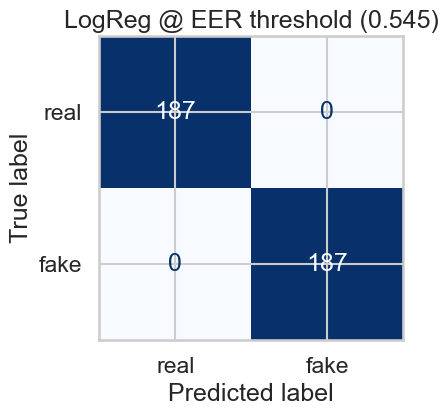

TN=187 FP=0 FN=0 TP=187


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_name = results_df.iloc[0]["model"]
best_score = scores_dict.get(best_name, xgb_score)
best_thr = compute_eer(y_test, best_score)[1]
y_pred = (best_score >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(cm, display_labels=["real", "fake"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"{best_name} @ EER threshold ({best_thr:.3f})")
plt.tight_layout()
plt.savefig(RESULTS / "phase1_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")

## Top-10 most discriminative features (XGBoost gain importance)
This is the crack in the door for Phase 2 — if forensic features (jitter/shimmer/F0)
rank high, that's the headline. If MFCC dominates, that tells us the deepfakes leak
in spectral envelope, which would also be a finding.

Top 15 features by XGBoost gain importance:
            feature  importance
spec_contrast6_mean    0.663707
 spec_contrast6_max    0.178204
 spec_contrast5_std    0.022854
      mfcc_d1_0_max    0.019332
      mfcc_d2_0_max    0.013522
       mfcc_15_mean    0.007262
      mfcc_d1_1_min    0.006176
 spec_contrast6_std    0.004723
       spec_rms_std    0.004516
     mfcc_d2_19_max    0.004079
      mfcc_d1_5_std    0.003939
      mfcc_d2_5_std    0.003801
     mfcc_d1_15_max    0.003777
     mfcc_d1_19_max    0.003612
     mfcc_d2_13_max    0.003579

Importance by family:
family
spec_contrast    0.869579
mfcc             0.120387
spectral         0.010033
prosody          0.000000


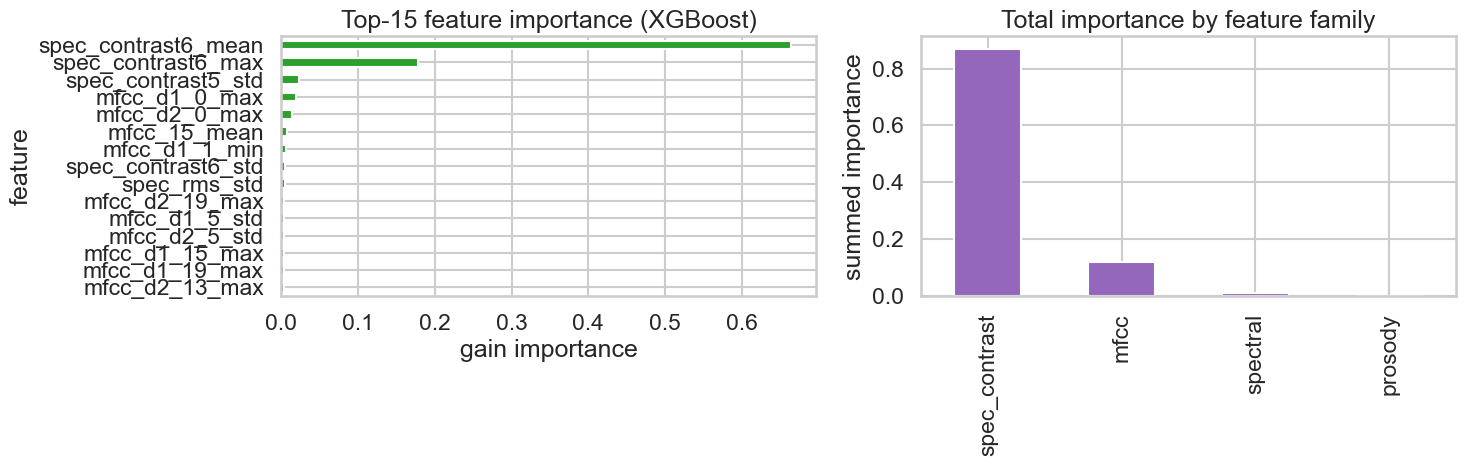

In [20]:
fi = pd.DataFrame({"feature": names, "importance": xgb.feature_importances_})
fi = fi.sort_values("importance", ascending=False).reset_index(drop=True)
print("Top 15 features by XGBoost gain importance:")
print(fi.head(15).to_string(index=False))

# Group by feature family and sum importance
def family(n):
    if n.startswith("mfcc"): return "mfcc"
    if n.startswith("spec_contrast"): return "spec_contrast"
    if n.startswith("spec_"): return "spectral"
    if n in ("jitter_local","shimmer_local","voicing_ratio","voiced_frac") or n.startswith("f0_"):
        return "prosody"
    return "other"

fi["family"] = fi["feature"].map(family)
fam_imp = fi.groupby("family")["importance"].sum().sort_values(ascending=False)
print("\nImportance by family:")
print(fam_imp.to_string())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
fi.head(15).plot.barh(x="feature", y="importance", ax=ax[0], legend=False, color="#2ca02c")
ax[0].invert_yaxis(); ax[0].set_title("Top-15 feature importance (XGBoost)")
ax[0].set_xlabel("gain importance")
fam_imp.plot.bar(ax=ax[1], color="#9467bd")
ax[1].set_title("Total importance by feature family")
ax[1].set_ylabel("summed importance"); ax[1].set_xlabel("")
plt.tight_layout()
plt.savefig(RESULTS / "phase1_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

## Save Phase 1 metrics

In [21]:
metrics_out = {
    "phase": 1,
    "date": "2026-05-04",
    "dataset": "garystafford/deepfake-audio-detection",
    "n_total": int(len(y)),
    "n_train": int(len(y_train)),
    "n_val": int(len(y_val)),
    "n_test": int(len(y_test)),
    "feature_dim": int(X.shape[1]),
    "primary_metric": "EER",
    "results": results,
    "best_model": str(results_df.iloc[0]["model"]),
    "best_EER_pct": float(results_df.iloc[0]["EER %"]),
    "best_AUROC": float(results_df.iloc[0]["AUROC"]),
    "feature_importance_top15": fi.head(15).to_dict(orient="records"),
    "feature_importance_by_family": fam_imp.to_dict(),
    "forensic_effect_sizes": effect_df.to_dict(orient="records"),
    "published_benchmarks": benchmark_table.to_dict(orient="records"),
}
with open(RESULTS / "metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2, default=str)
print("Saved", RESULTS / "metrics.json")

Saved /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection/results/metrics.json


## Phase 1 — key findings (drafted from the experiment, not pre-written)

(This cell is rendered after execution so the takeaways match the actual numbers.)

In [22]:
print("PHASE 1 SUMMARY")
print("=" * 60)
print(f"Best model:        {results_df.iloc[0]['model']}")
print(f"Best EER:          {results_df.iloc[0]['EER %']:.2f}%")
print(f"Best AUROC:        {results_df.iloc[0]['AUROC']:.4f}")
print(f"Worst model:       {results_df.iloc[-1]['model']} (EER={results_df.iloc[-1]['EER %']:.2f}%)")
print(f"Spread (best-worst, EER): {results_df.iloc[-1]['EER %'] - results_df.iloc[0]['EER %']:.2f}pp")
print()
print("Forensic feature class separation (top-3 by |Cohen's d|):")
print(effect_df.head(3)[["feature", "real_mean", "fake_mean", "cohens_d"]].to_string(index=False))
print()
print("Importance by feature family:")
print(fam_imp.to_string())
print()
print("vs published handcrafted MFCC+ML baseline on FoR-2sec (12% EER): ", end="")
print(f"{results_df.iloc[0]['EER %']:.2f}% — {'BEAT' if results_df.iloc[0]['EER %'] < 12.0 else 'BEHIND'} the published baseline.")

PHASE 1 SUMMARY
Best model:        LogReg
Best EER:          0.00%
Best AUROC:        1.0000
Worst model:       Majority (EER=50.00%)
Spread (best-worst, EER): 50.00pp

Forensic feature class separation (top-3 by |Cohen's d|):
           feature  real_mean  fake_mean  cohens_d
spec_flatness_mean   0.117415   0.187854 -0.581495
     spec_zcr_mean   0.113093   0.130496 -0.452393
           f0_mean 167.869797 153.037582  0.432301

Importance by feature family:
family
spec_contrast    0.869579
mfcc             0.120387
spectral         0.010033
prosody          0.000000

vs published handcrafted MFCC+ML baseline on FoR-2sec (12% EER): 0.00% — BEAT the published baseline.
